In [2]:
from nrem_analysis.constant import RAW_DIR, PROCESSED_DIR, INTERIM_DIR, FIGURES_DIR
from pathlib import Path

import numpy as np
import pynapple as nap
import matplotlib.pyplot as plt
import seaborn as sns

from cmap import Colormap
from matplotlib.colors import TwoSlopeNorm
from scipy import stats

MOUSE_IDS = ["99b", "103c", "106b", "107b", "110b"]

cm = Colormap("colorbrewer:Set2")
norm = TwoSlopeNorm(vmin=-25, vcenter=0, vmax=25)
dashed_style = (0, (5, 5))

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "sans-serif",
    'font.sans-serif':   "Arial",
    "axes.grid":         False,
    "figure.constrained_layout.use": True,
})

def plot_heatmaps(mats, times, titles, norm=None, cmap="hot", figsize=None):
    """Plot [T, N] matrices as side-by-side heatmaps."""
    n = len(mats)

    if figsize is None:
        figsize = (4 * n, 4)

    fig, axes = plt.subplots(
        1, n, figsize=figsize, sharey=True, squeeze=False
    )
    axes = axes.ravel()

    for ax, mat, time, title in zip(axes, mats, times, titles):
        im = ax.imshow(
            mat.T,
            aspect="auto",
            origin="lower",
            extent=[time[0], time[-1], 0, mat.shape[1]],
            cmap=cmap,
            norm=norm,
        )

        ax.set_title(title)
        fig.colorbar(im, ax=ax)

    return fig, axes

def time_index(t, target):
    return np.argmin(np.abs(t - target))

def amplitude_at_threshold(sta, t, threshold):
    before_idx = time_index(t, -threshold)
    after_idx = time_index(t, threshold)
    return sta[after_idx, :] - sta[before_idx, :]

def plot_scatter_with_regression(ax, x, y, title=None, xlabel=None, ylabel=None, line_color='tab:red', scatter_color='k'):
    fit = stats.linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = fit.intercept + fit.slope * x_fit

    ax.scatter(x, y, s=15, c=scatter_color, alpha=0.8)
    ax.plot(x_fit, y_fit, color=line_color, linewidth=0.7, linestyle='--')
    ax.axhline(0, color='0.5', linestyle='--', linewidth=1)
    ax.axvline(0, color='0.5', linestyle='--', linewidth=1)

    label = (
        f'R = {fit.rvalue:.2f}\n'
        f'p = {fit.pvalue:.2g}\n'
    )

    ax.text(0.05, 0.95, label, transform=ax.transAxes, ha='left', va='top', fontsize=14)
    if title is not None:
        ax.set_title(title, fontsize=18)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=18)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=18)

In [3]:
tsi = []
vtsi = []
sta_nrem = []

for mouse_id in MOUSE_IDS:
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")  

    sta = nap.load_file(INTERIM_DIR / "sta" / mouse_id / "sta_nrem_upstate.npz")    
    if sta.shape[0] == 103:
        sta = sta[1:-1]

    times = sta.t
    sta_nrem.append(sta.d)
    tsi.append(turn_units['turn_index'])
    vtsi.append(turn_units['virtual_turn_index'])

tsi = np.concatenate(tsi)
vtsi = np.concatenate(vtsi)
order = np.argsort(tsi)
tsi = tsi[order]
vtsi = vtsi[order]

sta_nrem = np.rad2deg(np.column_stack(sta_nrem))[:, order]
sta_original = nap.load_file(PROCESSED_DIR / "dual" / "sta_awake_sorted.npz")
print(sta_original.shape)

# Remove unit with NaN STA
nanmask = np.any(np.isnan(sta_nrem), axis=0)
tsi = tsi[~nanmask]
vtsi = vtsi[~nanmask]
zero_cross = np.argmin(np.abs(tsi)).item()

sta_original = sta_original[:, ~nanmask]
sta_nrem = sta_nrem[:, ~nanmask]

# Remove unit with NaN virtual TSI
nanmask_vtsi = np.isnan(vtsi)
vtsi = vtsi[~nanmask_vtsi]
tsi = tsi[~nanmask_vtsi]
zero_cross = np.argmin(np.abs(tsi)).item()

sta_original = sta_original[:, ~nanmask_vtsi]
sta_nrem = sta_nrem[:, ~nanmask_vtsi]

print(sta_original.shape, sta_nrem.shape)

(81, 79)
(81, 78) (101, 78)


In [4]:
sta_nrem = nap.TsdFrame(t=np.round(times, decimals=3), d=sta_nrem)
sta_nrem

Time (s)             0          1          2         3         4  ...
----------  ----------  ---------  ---------  --------  --------  -----
-0.05        4.06833     0.45194    0.920768   1.85528  -4.48328  ...
-0.049       3.91571     0.647142   0.964899   1.68795  -4.53251  ...
-0.048       3.92483     0.789165   0.297521   1.55953  -4.89935  ...
-0.047       4.11276     0.644298   0.305354   1.36397  -4        ...
-0.046       3.89977     0.597432   0.463205   1.63566  -3.46086  ...
-0.045       4.09681     0.658501   0.453952   1.02994  -4.90158  ...
-0.044       4.21184     0.792318   0.287089   1.04562  -4.50111  ...
...                                                               ...
0.044       -0.125273   -0.633407  -0.604296  -3.15333  -2.33787  ...
0.045       -0.144629   -0.598215  -0.639725  -3.43611  -3.44748  ...
0.046        0.194774   -0.61005   -0.52561   -3.3673   -2.72937  ...
0.047        0.314357   -0.589377  -0.566099  -3.447    -2.6354   ...
0.048        0.345

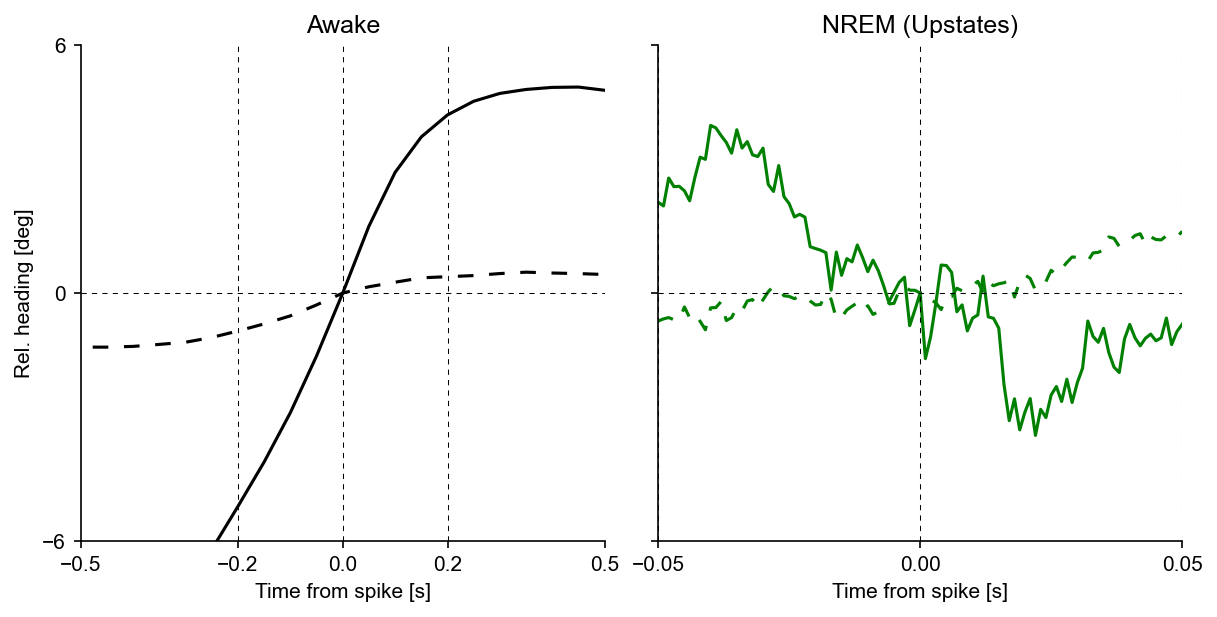

In [32]:
f, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

axes[0].plot(sta_original.index, sta_original.values[:, 39], linestyle=(0, (5, 5)), color='k')
axes[0].plot(sta_original.index, sta_original.values[:, 64], color='k')
axes[0].set_ylabel("Rel. heading [deg]")

axes[0].set_xticks([-0.5, -.2, 0, .2, 0.5])
axes[0].set_yticks([-6, 0, 6])
axes[0].set_xlim([-0.5, 0.5])
axes[0].set_ylim([-6, 6])
axes[0].set_title('Awake')

axes[0].axvline(x=0.2, color='k', linestyle=dashed_style, linewidth=0.5)
axes[0].axvline(x=-0.2, color='k', linestyle=dashed_style, linewidth=0.5)

axes[1].plot(sta_nrem.index, sta_nrem.values[:, 39], linestyle=(0, (5, 5)), color='g')
axes[1].plot(sta_nrem.index, sta_nrem.values[:, 64], color='g')
axes[1].set_title('NREM (Upstates)')


axes[1].set_xlim([-.05, .05])
axes[1].set_xticks([-0.05, 0, 0.05])
axes[1].axvline(x=0.05, color='k', linestyle=dashed_style, linewidth=0.5)
axes[1].axvline(x=-0.05, color='k', linestyle=dashed_style, linewidth=0.5)

for ax in axes:
    ax.axhline(0, color='k', linestyle=dashed_style, linewidth=0.5)
    ax.axvline(0, color='k', linestyle=dashed_style, linewidth=0.5)
    ax.set_xlabel("Time from spike [s]")

sns.despine()
# plt.savefig(FIGURES_DIR / "turn_example.svg", format='svg', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / "turn_example.png", format='png', bbox_inches='tight')

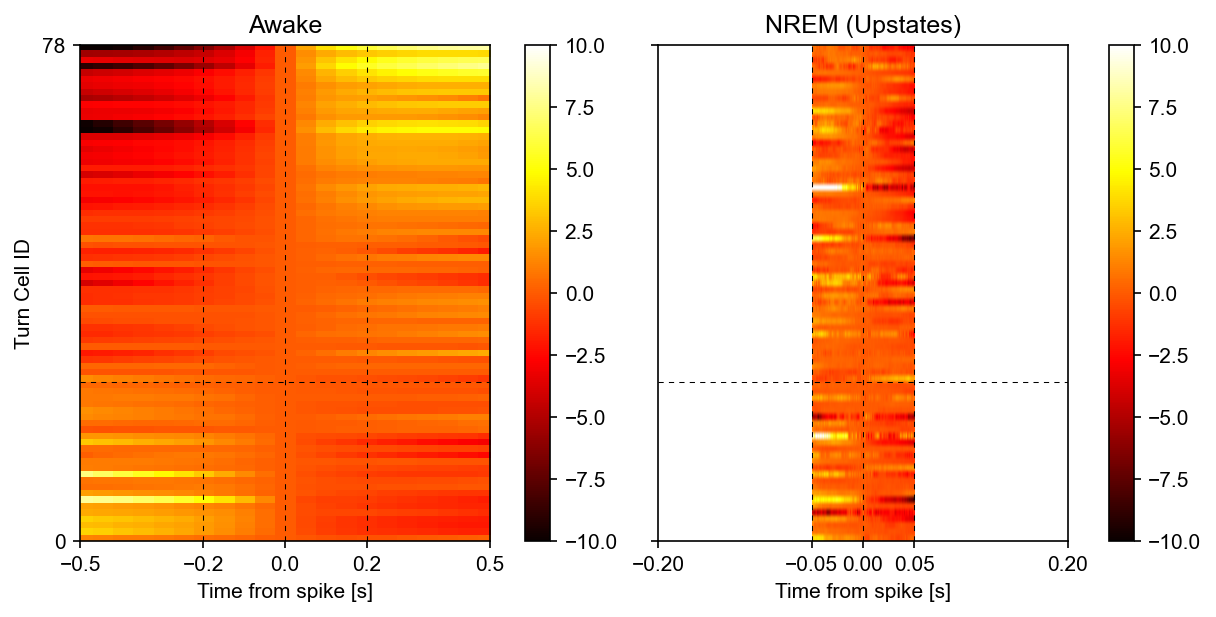

In [68]:
fig, axes = plot_heatmaps(
    mats=[sta_original.d, sta_nrem.d],
    times=[sta_original.t, sta_nrem.t],
    titles=["Awake", "NREM (Upstates)"],
    norm=TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10),
)

for ax in axes:
    ax.axvline(0, color="k", linestyle=dashed_style, linewidth=0.5)
    ax.axhline(zero_cross, color="k", linestyle=dashed_style, linewidth=0.5)
    ax.set_xlabel("Time from spike [s]")

axes[0].set_ylabel("Turn Cell ID")
axes[0].set_xlim([-0.5, 0.5])
axes[0].set_xticks([-0.5, -.2, 0, .2, 0.5])
axes[0].set_yticks([0, len(sta_original.columns)])
axes[0].axvline(0.2, color="k", linestyle=dashed_style, linewidth=0.5)
axes[0].axvline(-0.2, color="k", linestyle=dashed_style, linewidth=0.5)

axes[1].set_xlim((-.2, .2))
axes[1].set_xticks([-0.2, -.05, 0, .05, 0.2])
axes[1].axvline(0.05, color="k", linestyle=dashed_style, linewidth=0.5)
axes[1].axvline(-0.05, color="k", linestyle=dashed_style, linewidth=0.5)

# plt.savefig(FIGURES_DIR / "sta_norm.svg", format='svg', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / "sta_norm.png", format='png', bbox_inches='tight')

plt.show()

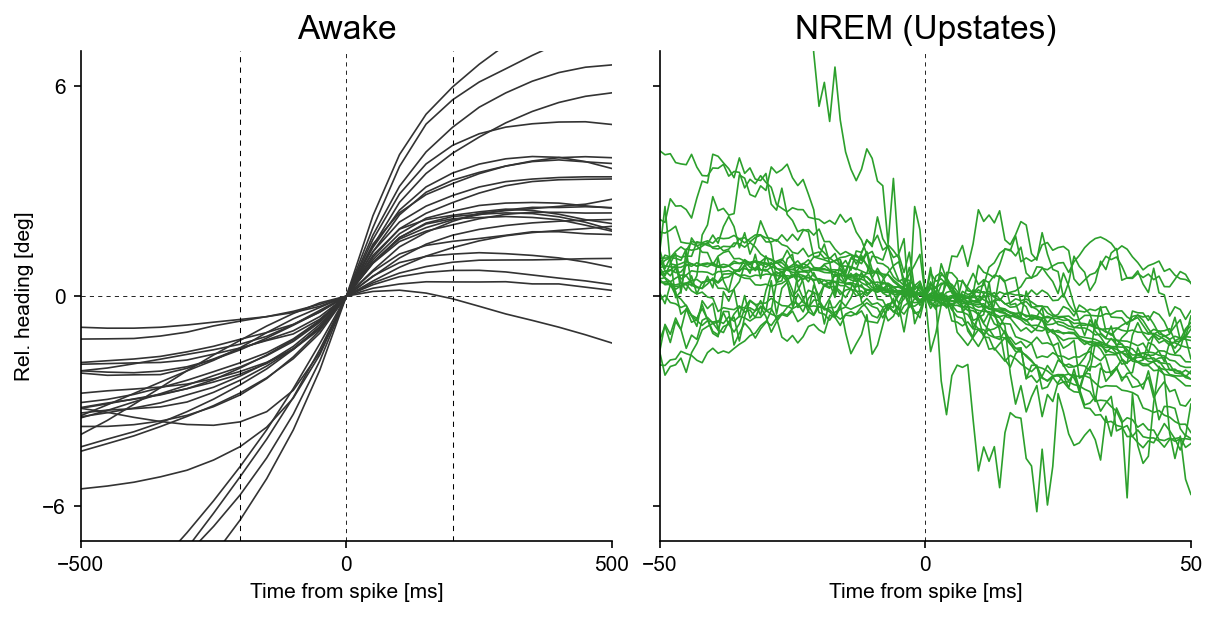

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
axes = axes.flatten()

mask = (tsi>0.2) & (vtsi>0.2)

axes[0].plot(sta_original.times('ms'), sta_original[:, mask], color='0.2', linewidth=0.8)
axes[0].set_ylabel("Rel. heading [deg]")
axes[0].set_xlim([-500, 500])
axes[0].set_xticks([-500, 0, 500])

axes[0].set_ylim([-7, 7])
axes[0].set_yticks([-6, 0, 6])

axes[0].axvline(x=200, color='k', linestyle=dashed_style, linewidth=0.5)
axes[0].axvline(x=-200, color='k', linestyle=dashed_style, linewidth=0.5)
axes[0].set_title(f"Awake", fontsize=16)

axes[1].plot(sta_nrem.times('ms'), sta_nrem[:, mask], color='tab:green', linewidth=0.8)
axes[1].set_xlim([-50, 50])
axes[1].set_xticks([-50, 0, 50])
# axes[1].axvline(x=20, color='k', linestyle=dashed_style, linewidth=0.5)
# axes[1].axvline(x=-20, color='k', linestyle=dashed_style, linewidth=0.5)
axes[1].set_title(f"NREM (Upstates)", fontsize=16)

for ax in axes:
    ax.axhline(y=0, color='k', linestyle=dashed_style, linewidth=0.4)
    ax.axvline(x=0, color='k', linestyle=dashed_style, linewidth=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)    
    ax.set_xlabel("Time from spike [ms]")

# fig.suptitle("TSI>0.2 Turn Cells", fontsize=18)
plt.savefig(FIGURES_DIR / "sta" / "sta_cw_turns.png", format='png', bbox_inches='tight', dpi=320)
plt.savefig(FIGURES_DIR / "sta" /"sta_cw_turns.svg", format='svg', bbox_inches='tight', dpi=320)
plt.show()

In [7]:
turn_amps_awake         = amplitude_at_threshold(sta_original, sta_original.t, 0.2)
turn_amps_nrem          = amplitude_at_threshold(sta_nrem, sta_nrem.t, 0.05)

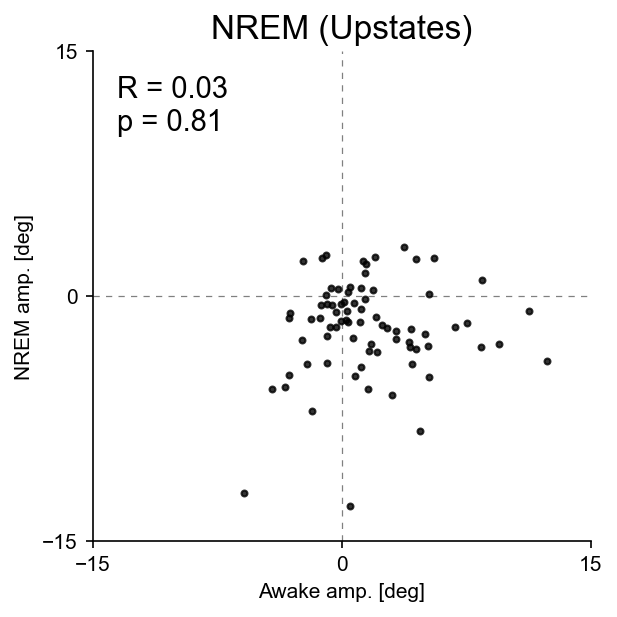

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

x, y = turn_amps_awake, turn_amps_nrem

fit = stats.linregress(x, y)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = fit.intercept + fit.slope * x_fit

ax.scatter(x, y, s=8, c='k', alpha=0.8)
# ax.plot(x_fit, y_fit, color='tab:red', linewidth=0.7, linestyle='--')
ax.axhline(0, color='0.5', linestyle=dashed_style, linewidth=0.6, zorder=0)
ax.axvline(0, color='0.5', linestyle=dashed_style, linewidth=0.6, zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel("Awake amp. [deg]")

label = (
    f'R = {fit.rvalue:.2f}\n'
    f'p = {fit.pvalue:.2g}\n'
)

ax.text(0.05, 0.95, label, transform=ax.transAxes, ha='left', va='top', fontsize=14)
ax.set_xticks([-15, 0, 15])
ax.set_yticks([-15, 0, 15])
ax.set_xlim([-15, 15])
ax.set_ylim([-15, 15])

ax.set_title("NREM (Upstates)", fontsize=16)
ax.set_ylabel('NREM amp. [deg]')

plt.savefig(FIGURES_DIR / "sta" / "turn_amplitude_scatter.svg", format='svg', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "sta" / "turn_amplitude_scatter.png", format='png', bbox_inches='tight')

Text(0.5, 0.98, 'Turn Amplitude vs TSI')

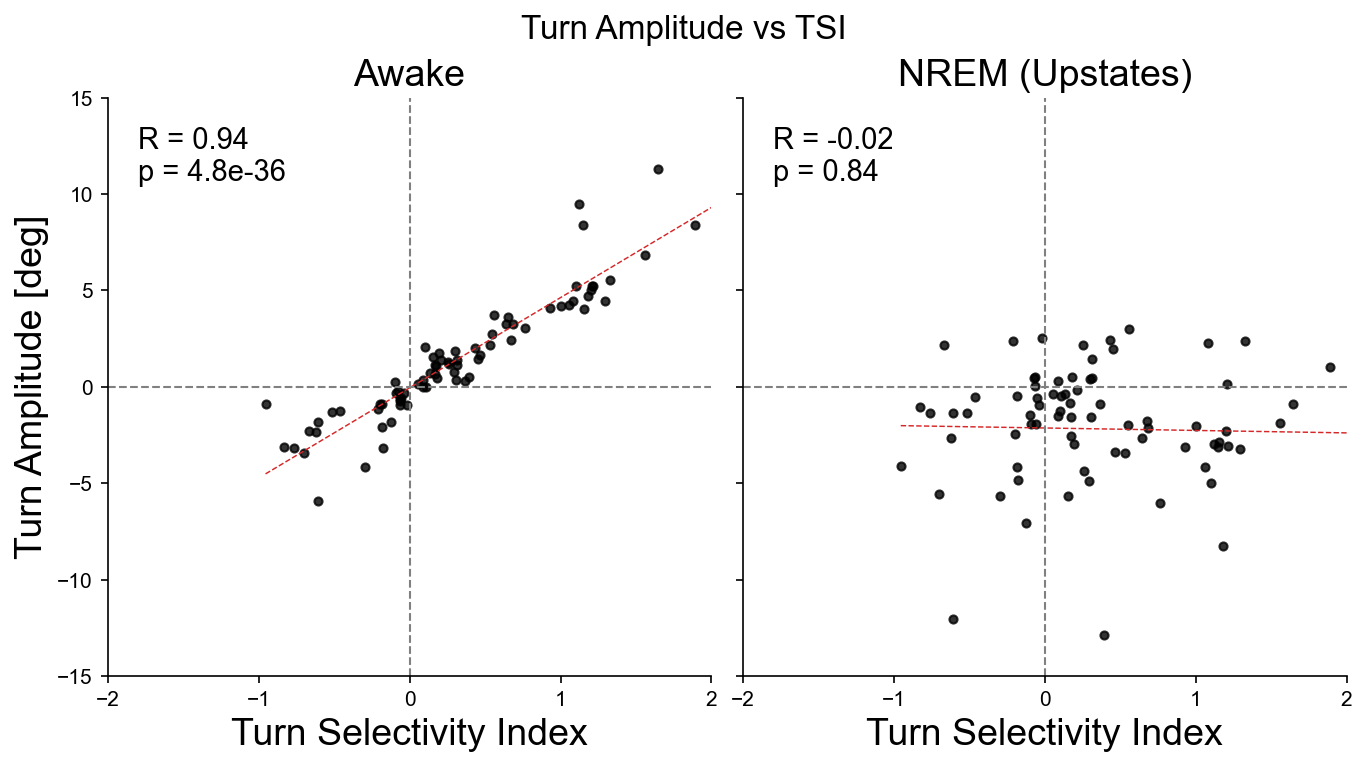

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharex=True, sharey=True, constrained_layout=True)

plot_scatter_with_regression(axes[0], tsi, turn_amps_awake, 'Awake', xlabel='Turn Selectivity Index', ylabel='Turn Amplitude [deg]')
plot_scatter_with_regression(axes[1], tsi, turn_amps_nrem, 'NREM (Upstates)', xlabel='Turn Selectivity Index', ylabel='')


for ax in axes:
    ax.set_xlim((-2, 2))
    ax.set_ylim((-15, 15))
    ax.set_xticks([-2, -1, 0, 1, 2])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle("Turn Amplitude vs TSI", fontsize=16)

# plt.savefig(FIGURES_DIR / "sta" / "turn_scatter_tsi.svg", format='svg', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / "sta" / "turn_scatter_tsi.png", format='png', bbox_inches='tight')